# Notebook 3: Data Preprocessing & Statistical Analysis

Sections 9–15: Creating the churn target variable, merging with the final dataframe, outlier treatment, missing value treatment, multivariate analysis, statistical tests, and data transformation.

**Prerequisite:** Run Notebooks 1 & 2 first to generate merged.csv, final.csv, rfm.csv

**Team role:** Data Preprocessing & Statistical Analysis

**Team:** FEHU | **Dataset:** Olist Brazilian E-Commerce | **Track:** Business & Retail

In [28]:
# Load intermediate data produced by Notebooks 1 & 2
# Ensure merged.csv, final.csv, and rfm.csv are saved before running this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from warnings import filterwarnings
filterwarnings("ignore")

merged = pd.read_csv("merged.csv", parse_dates=["order_purchase_timestamp"])
final  = pd.read_csv("final.csv")
rfm    = pd.read_csv("rfm.csv")
print("merged:", merged.shape, "| final:", final.shape, "| rfm:", rfm.shape)

merged: (111468, 24) | final: (90528, 21) | rfm: (90528, 9)


<a id="target"></a>
# 9. Creating a target variable

In [29]:
rfm['Churn'] = rfm.Recency.apply(lambda x: 1 if x > rfm.Recency.mean() else 0)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,recency_label,monetary_label,frequency_label,Rank,rank_rm,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,1,2,4,"(1, 2, 4)","(1, 2)",0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,1,4,4,"(1, 4, 4)","(1, 4)",0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,3,4,"(4, 3, 4)","(4, 3)",1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3,4,4,"(3, 4, 4)","(3, 4)",1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3,2,4,"(3, 2, 4)","(3, 2)",1


**Observations:**
1. The **churn rate**, also known as the **rate of attrition** or customer churn, is the **rate at which customers stop doing business with an entity**. 
2. We used the **recency column to frame the target variable**. If the **customer's recency falls above the average** value of recency, we consider such customers as **churned**. The **rest of the customers** as **not churned**.
3. We used the **mean of recency as the threshold** as the **recency is normally** or symmetrically distributed. 
4. We will have to **impute the target variable to the main dataframe** and do the further classification algorithm.

<a id="finaldf"></a>
# 10. Merging the target variable with our final dataframe

In [30]:
final = final.merge(rfm[['customer_unique_id', 'Recency', 'Monetary', 'Frequency', 'Churn']], on = 'customer_unique_id')
final.head()

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,no_of_orders,purchased_approved,delivered_estimated,purchased_delivered,no_of_products,price,...,geolocation_lat,geolocation_lng,payment_type,payment_installments,payment_value,review_score,Recency,Monetary,Frequency,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,1,891.0,4,6.0,1,129.90,...,-23.333580,-46.823060,credit_card,8,141.90,5.0,111,141.90,1,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,1,26057.0,4,3.0,1,18.90,...,-23.545029,-46.781482,credit_card,1,27.19,NaN,114,27.19,1,0
2,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,1,0.0,1,25.0,1,69.00,...,-27.532246,-48.618667,credit_card,8,86.22,NaN,537,86.22,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,66812,belem,PA,1,1176.0,11,20.0,1,25.99,...,-1.304189,-48.476339,credit_card,4,43.62,NaN,321,43.62,1,1
4,0004aac84e0df4da2b147fca70cf8255,18040,sorocaba,SP,1,1270.0,7,13.0,1,180.00,...,-23.496567,-47.462811,credit_card,6,196.89,NaN,288,196.89,1,1


In [31]:
records, features = final.shape
print('Total number of unique records: ', records)
print('Total number of features: ', features)

Total number of unique records:  90528
Total number of features:  25


In [32]:
final['Churn'] = final.Churn.astype('object')

<a id="out"></a>
# 11. Outlier Treatement

Skewness of customer_zip_code_prefix: 0.7815398325835958
Standard deviation of customer_zip_code_prefix: 29806.841040442094


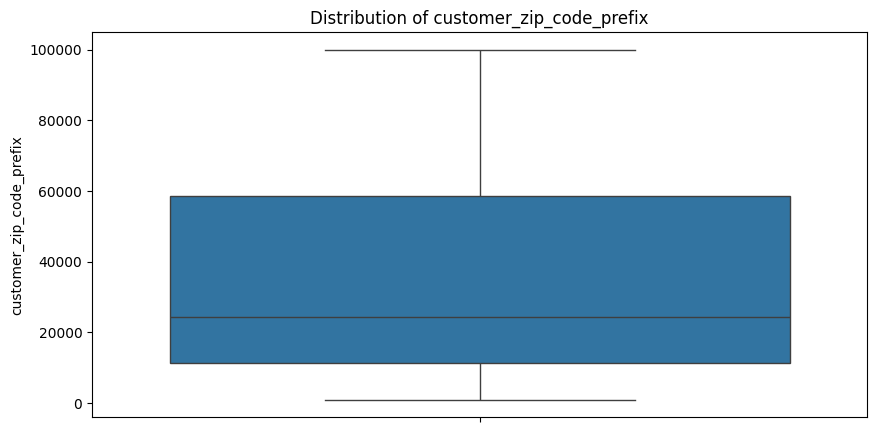

Skewness of no_of_orders: 10.676600298052568
Standard deviation of no_of_orders: 0.20649360862520988


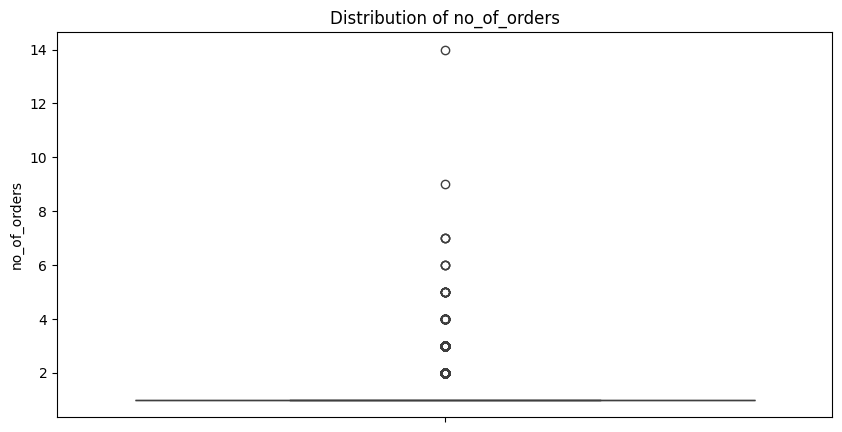

Skewness of purchased_approved: 1.6936517976235201
Standard deviation of purchased_approved: 23397.787779977294


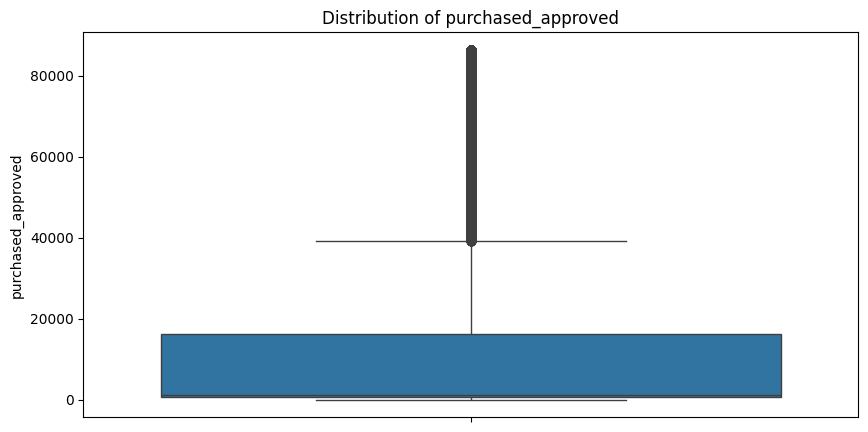

Skewness of delivered_estimated: -2.101764866389134
Standard deviation of delivered_estimated: 10.203242967048714


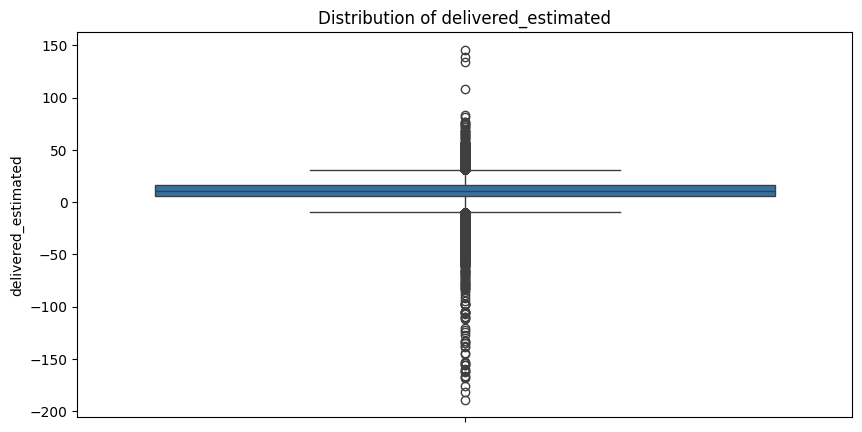

Skewness of purchased_delivered: 3.885615578737388
Standard deviation of purchased_delivered: 9.567765067052092


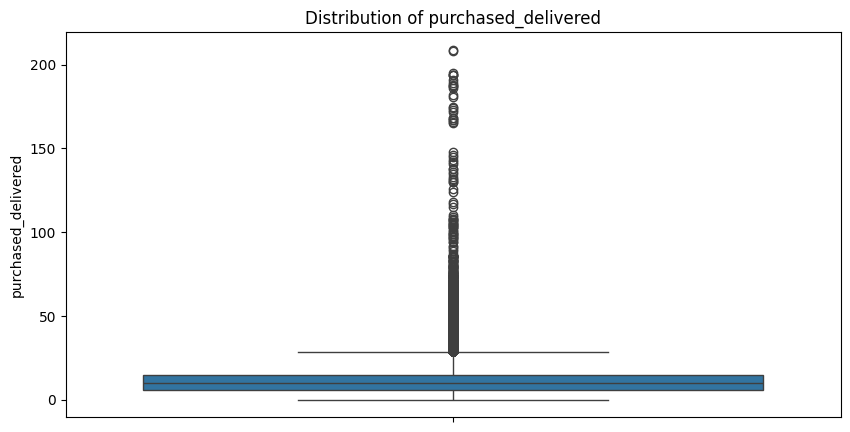

Skewness of no_of_products: 7.414378109080429
Standard deviation of no_of_products: 0.31373679944646404


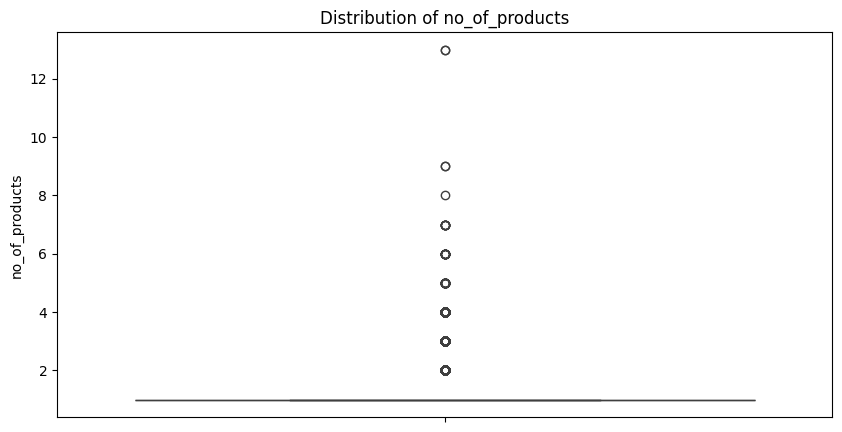

Skewness of price: 11.791837108894033
Standard deviation of price: 244.2877497694722


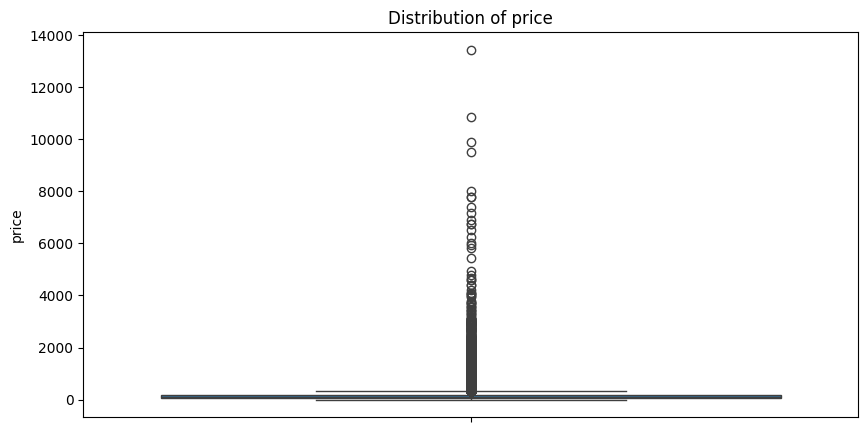

Skewness of freight_value: 13.696046608723156
Standard deviation of freight_value: 26.8905604707273


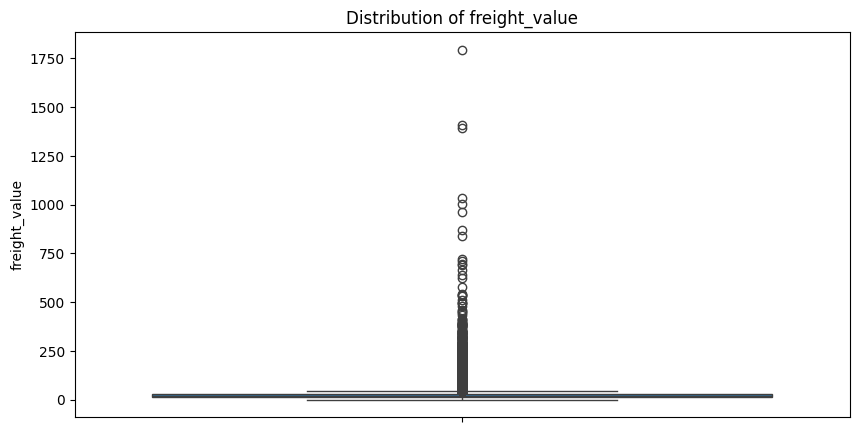

Skewness of product_weight_g: 12.131479466882134
Standard deviation of product_weight_g: 5812.313175955143


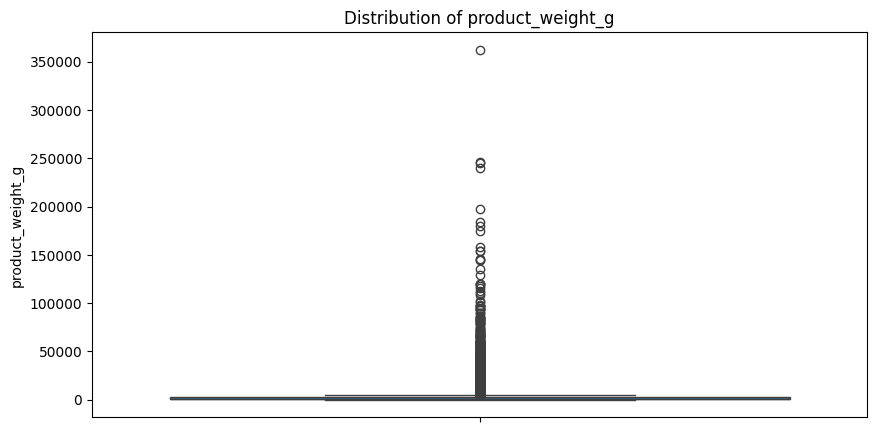

Skewness of product_length_cm: 16.000317045845396
Standard deviation of product_length_cm: 35.43155752809992


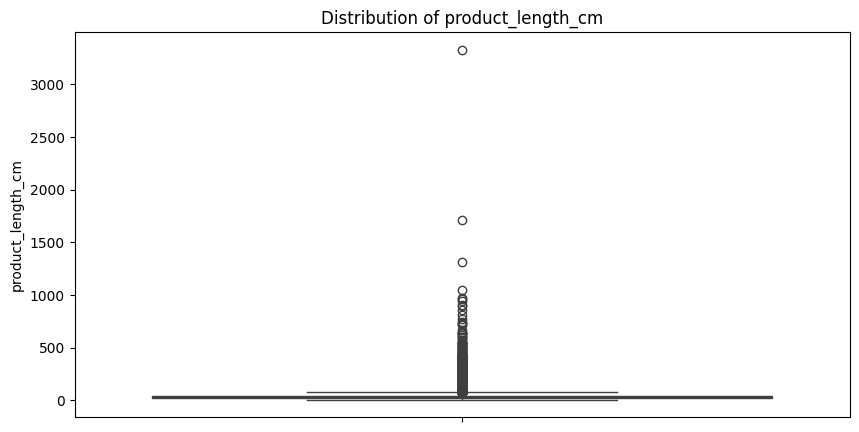

Skewness of product_height_cm: 14.445872079638715
Standard deviation of product_height_cm: 25.18795518390413


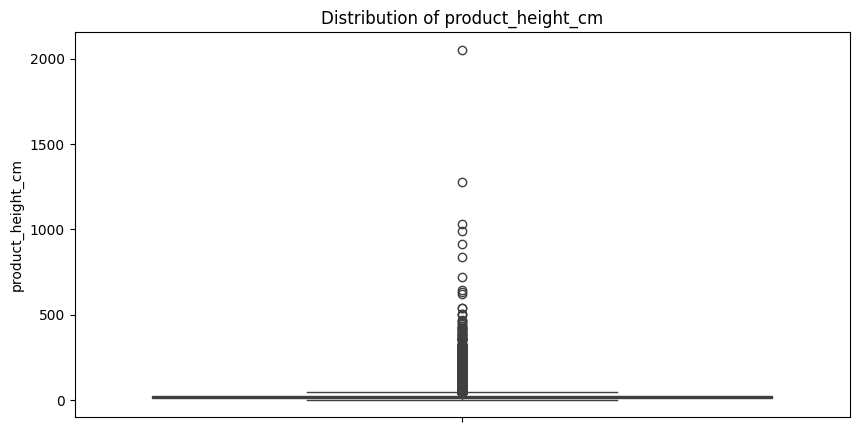

Skewness of product_width_cm: 16.47431670120788
Standard deviation of product_width_cm: 26.235366771941106


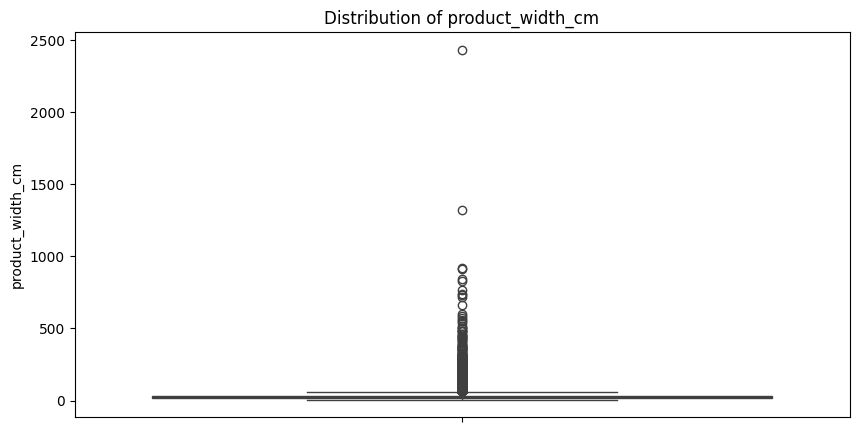

Skewness of geolocation_lat: 1.7731522011144614
Standard deviation of geolocation_lat: 5.683911480427562


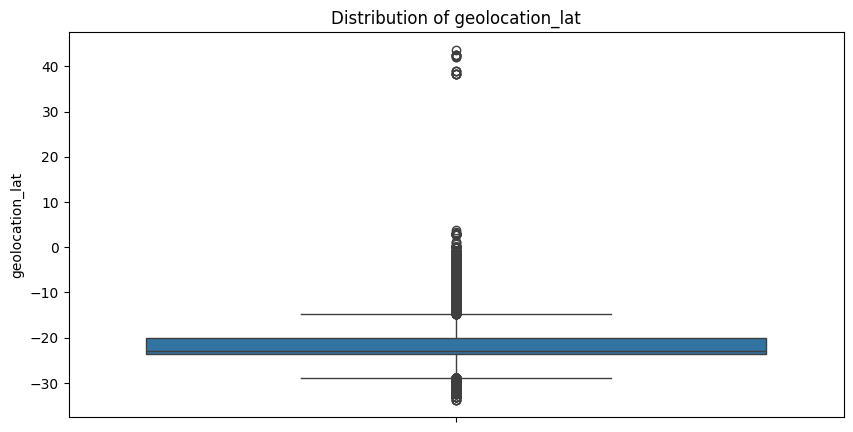

Skewness of geolocation_lng: 0.18920688857939136
Standard deviation of geolocation_lng: 4.095579090984354


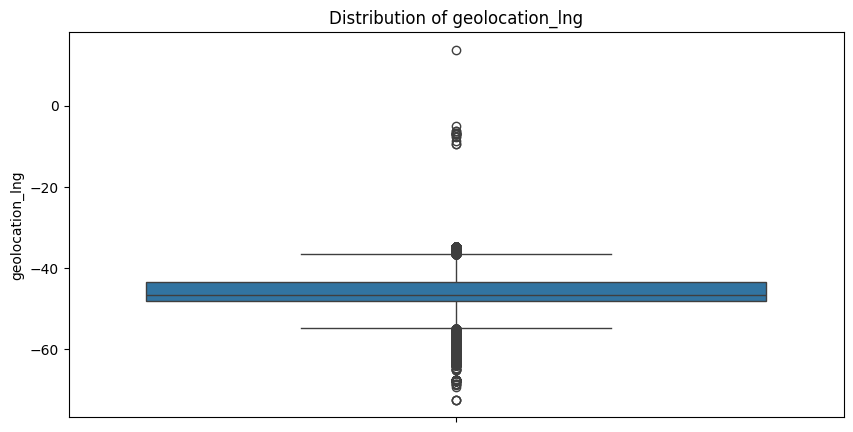

Skewness of payment_installments: 1.5985424567820286
Standard deviation of payment_installments: 2.728462973751188


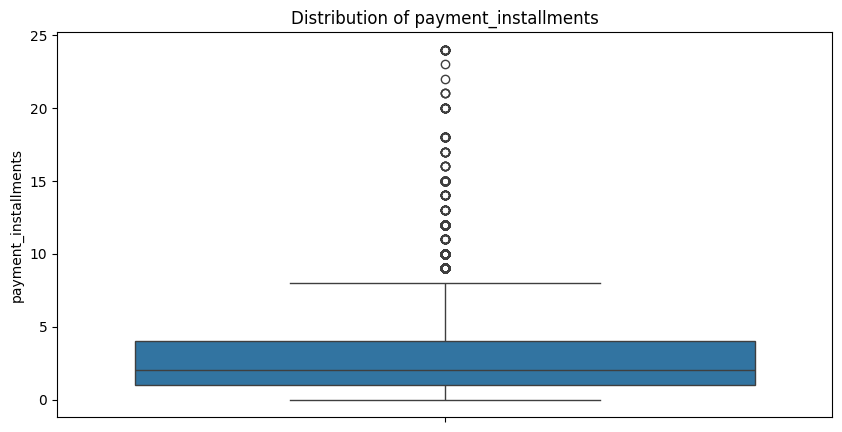

Skewness of payment_value: 70.4949829190865
Standard deviation of payment_value: 647.5936527572592


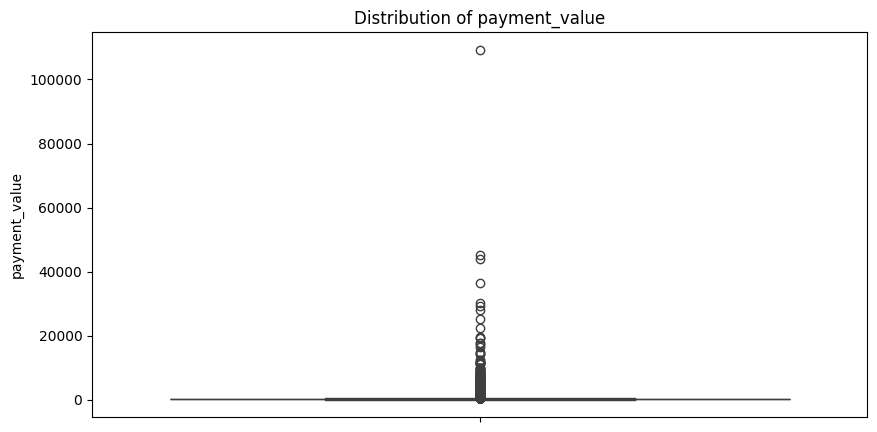

Skewness of review_score: -1.0689366055733671
Standard deviation of review_score: 1.5081853241987146


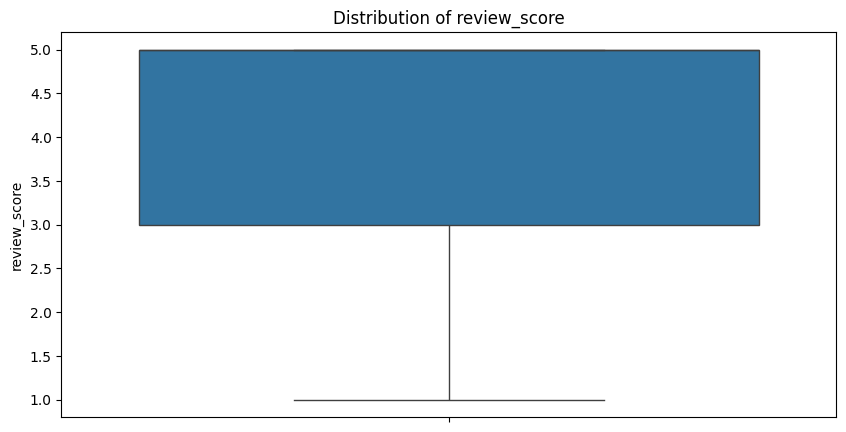

Skewness of Recency: 0.43585883202493925
Standard deviation of Recency: 152.38669351592222


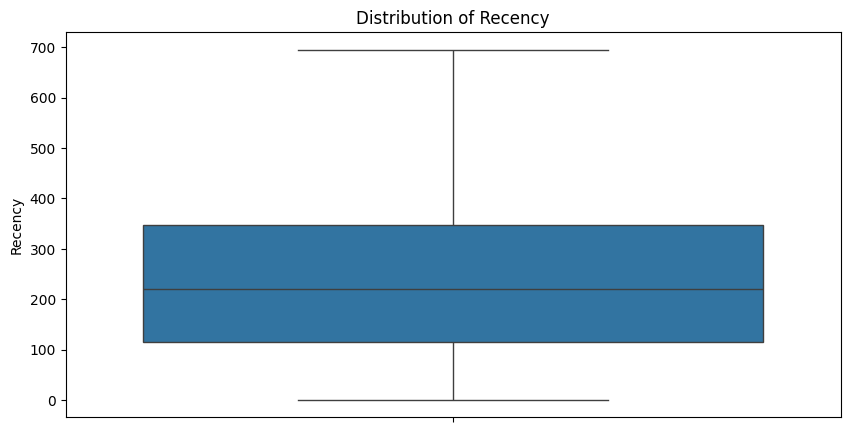

Skewness of Monetary: 70.4949829190865
Standard deviation of Monetary: 647.5936527572592


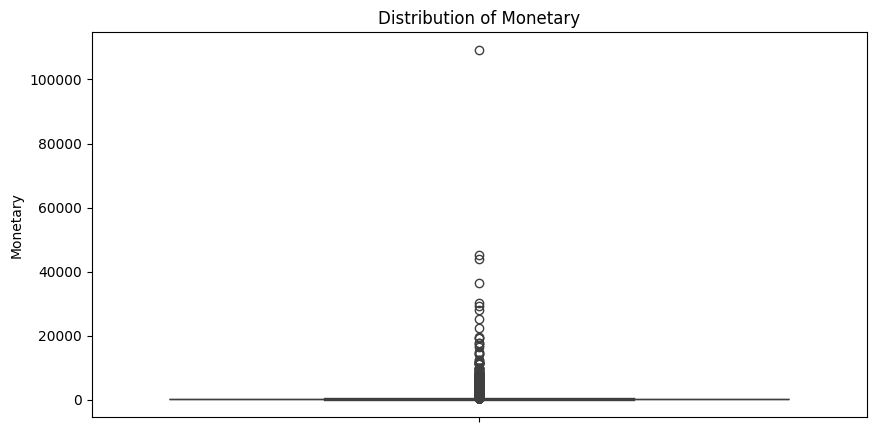

Skewness of Frequency: 10.676600298052568
Standard deviation of Frequency: 0.20649360862520988


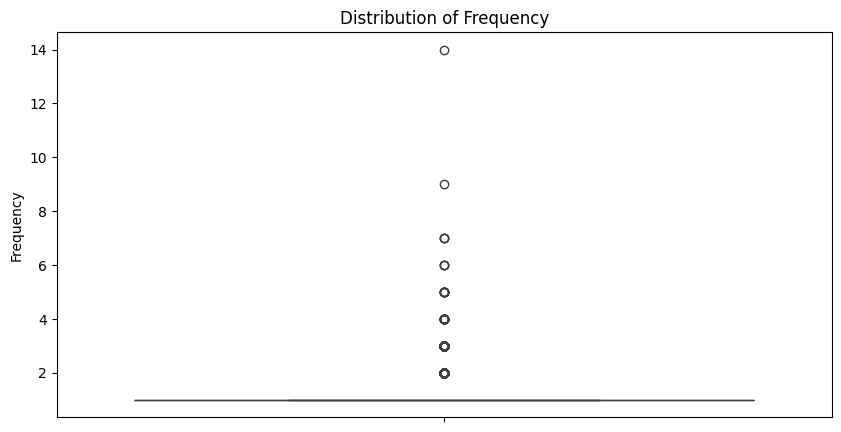

In [33]:
for col in final.select_dtypes(include = np.number).columns:
    plt.figure(figsize = (10, 5))
    print(f'Skewness of {col}: {final[col].skew()}')
    print(f'Standard deviation of {col}: {final[col].std()}')
    sns.boxplot(final[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [34]:
final.drop(columns = ['customer_zip_code_prefix', 'no_of_orders', 'no_of_products', 'Frequency'], axis = 1, inplace = True)

**Observation:**
1. Since the columns `no_of_orders`, `no_of_products` and `Frequency` has **standard deviation almost equal to 0**, we are **dropping those columns**, as it would **not add value to the model building**. 

In [35]:
final_outlierTreated = final.copy()

In [36]:
for i in final_outlierTreated.select_dtypes(include = np.number).columns:
    q1 = final_outlierTreated[i].quantile(0.25)
    q3 = final_outlierTreated[i].quantile(0.75)
    iqr = q3 - q1
    ul = q3 + 1.5*iqr
    ll = q1 - 1.5*iqr
    final_outlierTreated[i] = np.where(final_outlierTreated[i]>ul,ul,final_outlierTreated[i])
    final_outlierTreated[i] = np.where(final_outlierTreated[i]<ll,ll,final_outlierTreated[i])

Skewness of purchased_approved: 1.216427542911808
Standard deviation of purchased_approved: 15172.739925537338


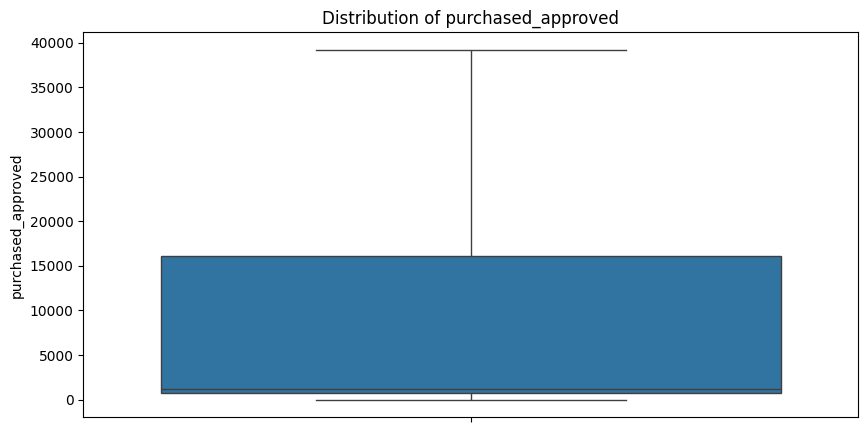

Skewness of delivered_estimated: -0.09874592372345704
Standard deviation of delivered_estimated: 8.274096249346677


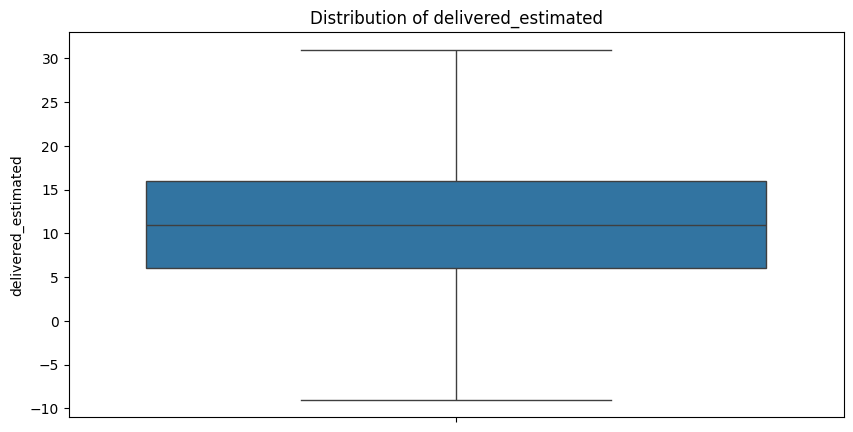

Skewness of purchased_delivered: 0.8756697985741126
Standard deviation of purchased_delivered: 7.115309691363529


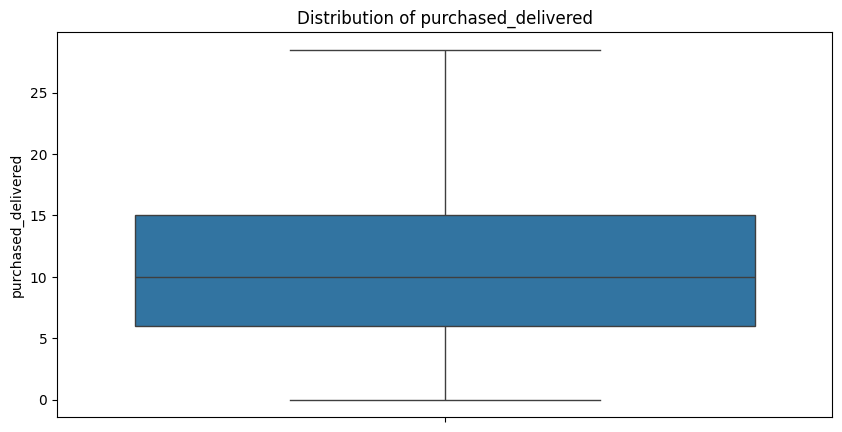

Skewness of price: 1.0621689422971194
Standard deviation of price: 92.20044361066198


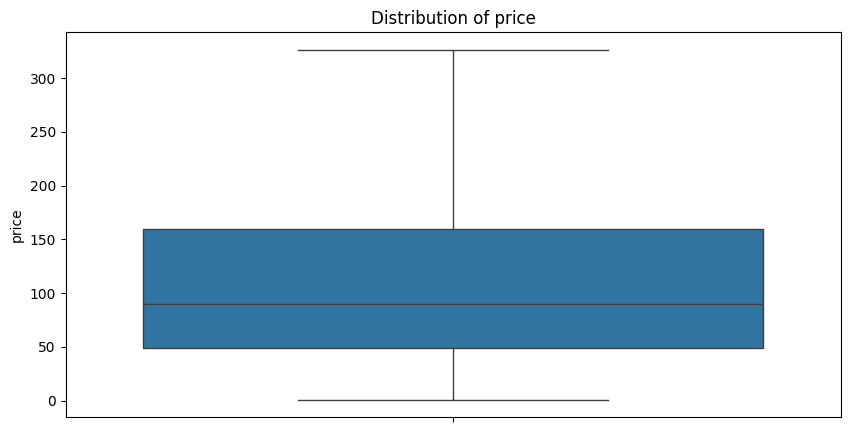

Skewness of freight_value: 0.9844226195345266
Standard deviation of freight_value: 11.097659947869786


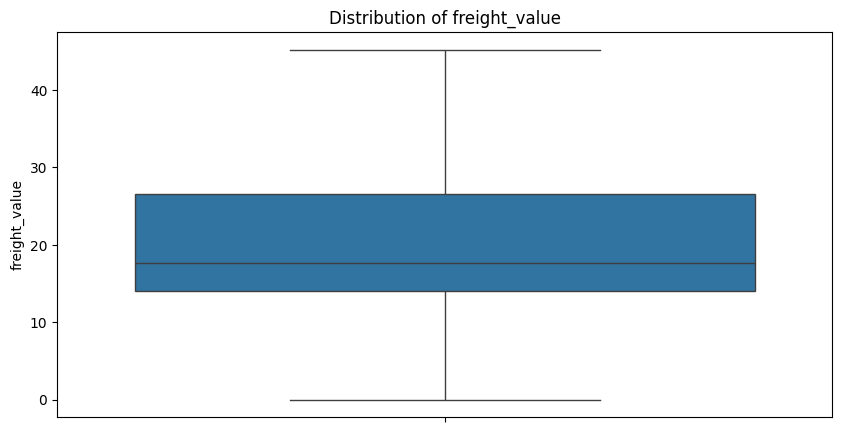

Skewness of product_weight_g: 1.184708672928979
Standard deviation of product_weight_g: 1768.577396432909


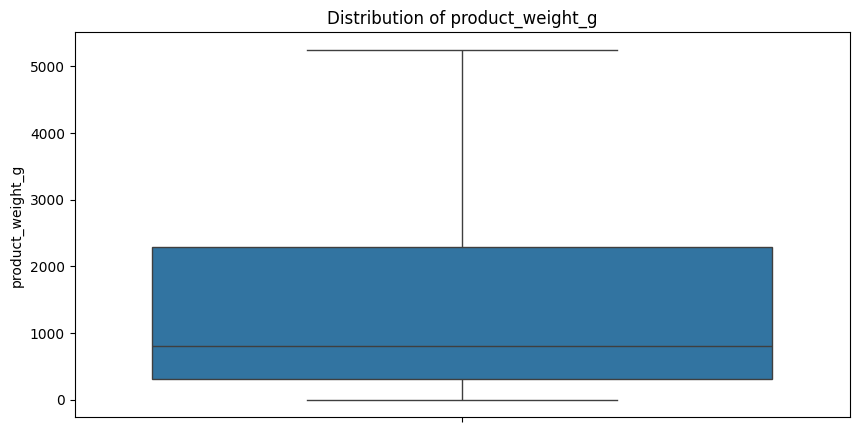

Skewness of product_length_cm: 1.0917311795460445
Standard deviation of product_length_cm: 18.785325900129585


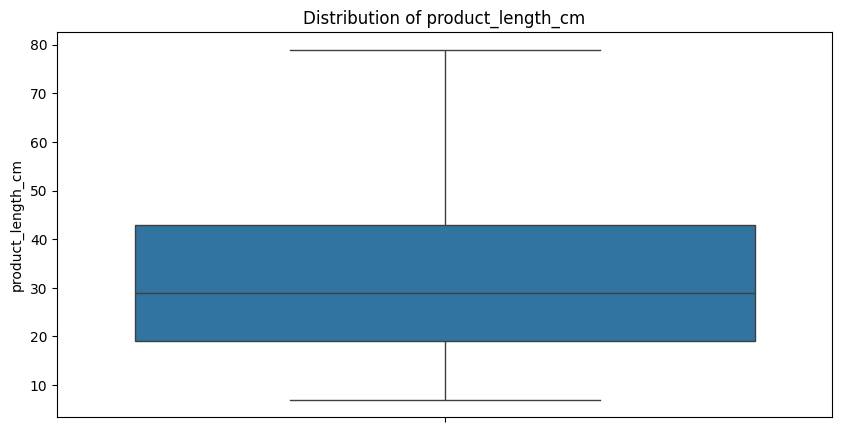

Skewness of product_height_cm: 0.9828445611757387
Standard deviation of product_height_cm: 12.625083800219741


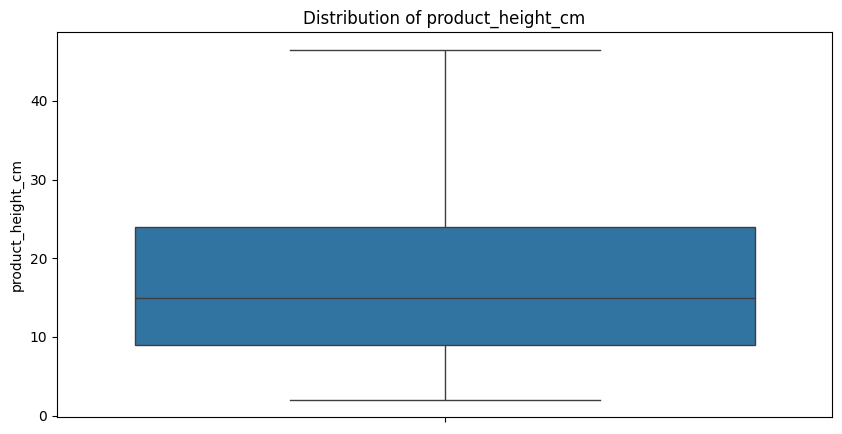

Skewness of product_width_cm: 1.125375095461402
Standard deviation of product_width_cm: 14.460754794476427


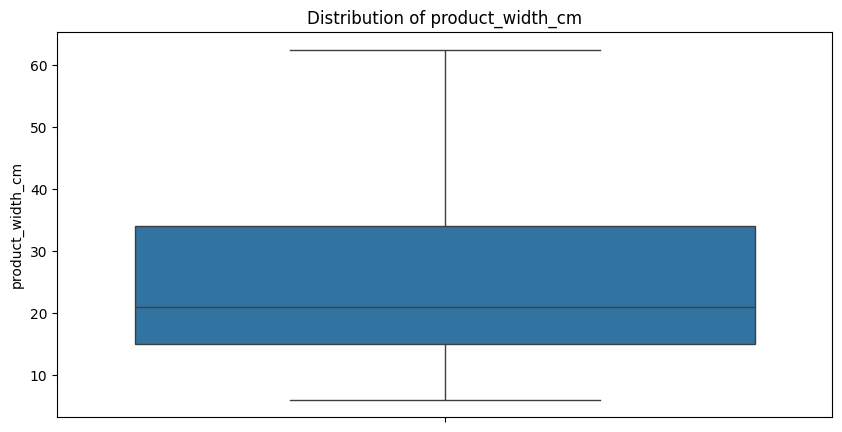

Skewness of geolocation_lat: 0.5304176813724053
Standard deviation of geolocation_lat: 3.6704632496030594


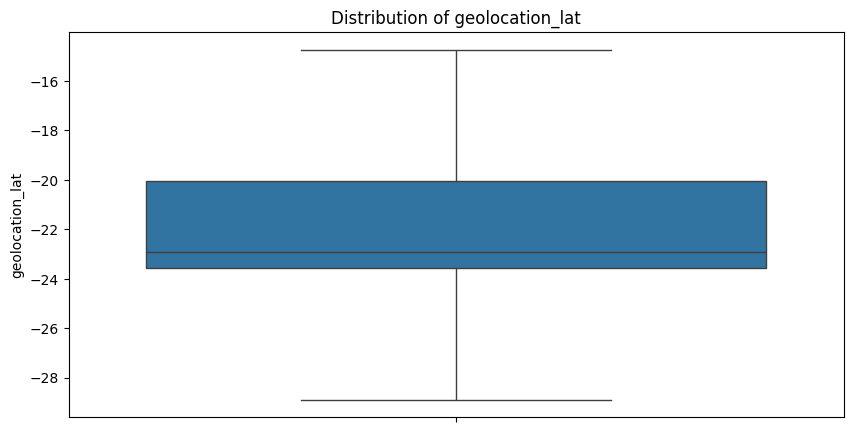

Skewness of geolocation_lng: 0.27977748830128457
Standard deviation of geolocation_lng: 3.8012245383733183


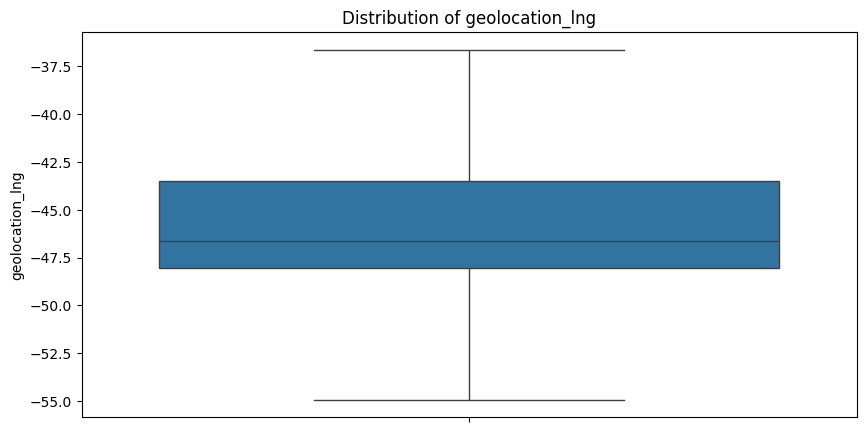

Skewness of payment_installments: 1.2118688690198518
Standard deviation of payment_installments: 2.4396707220778495


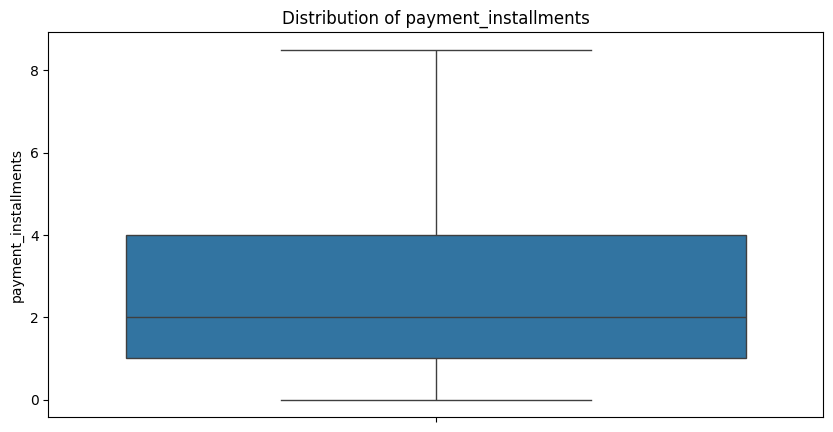

Skewness of payment_value: 1.0925860647703838
Standard deviation of payment_value: 117.11471507512535


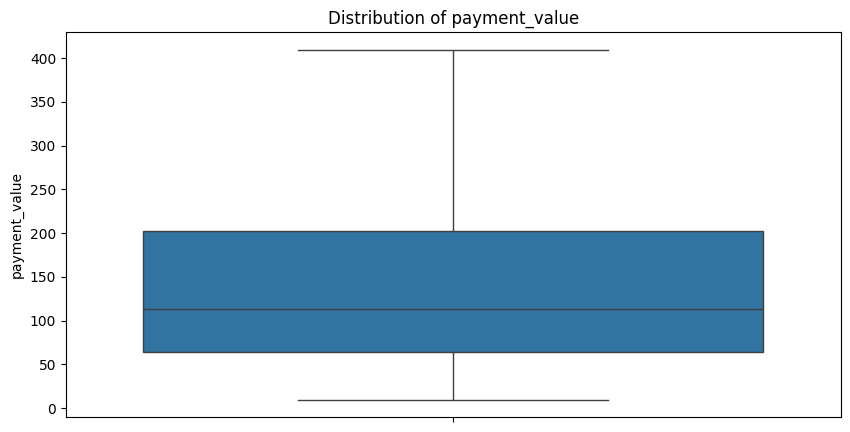

Skewness of review_score: -1.0689366055733671
Standard deviation of review_score: 1.5081853241987146


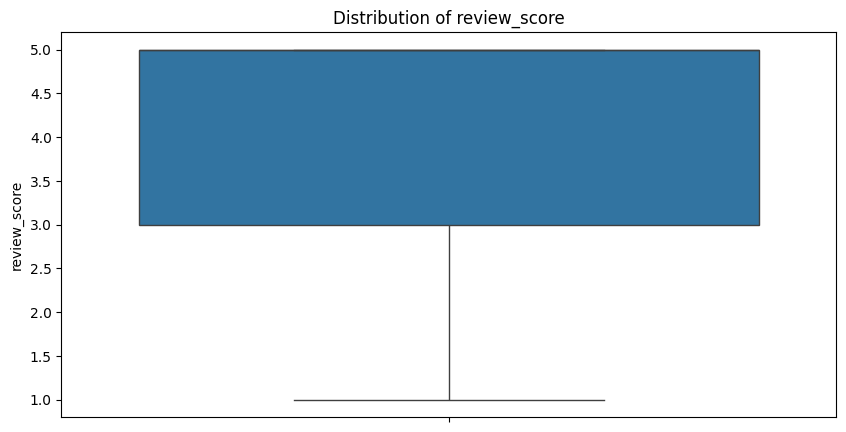

Skewness of Recency: 0.43585883202493925
Standard deviation of Recency: 152.38669351592222


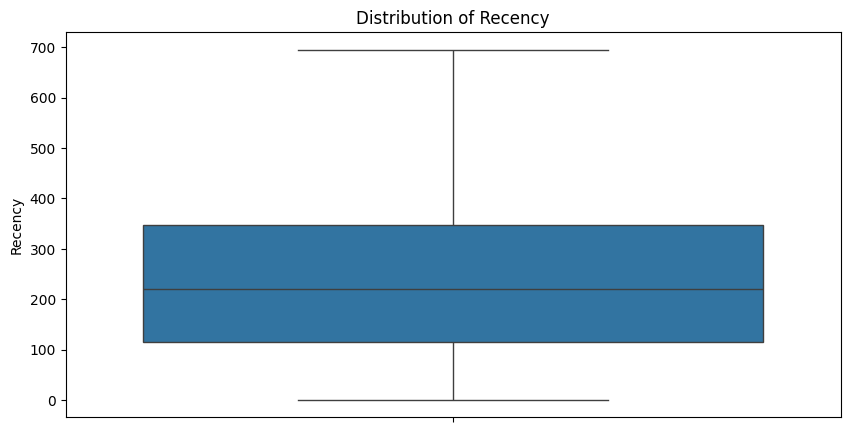

Skewness of Monetary: 1.0925860647703838
Standard deviation of Monetary: 117.11471507512535


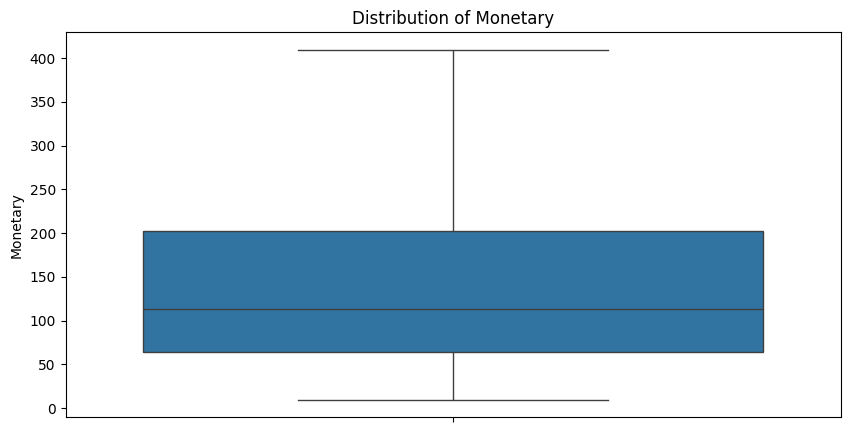

In [37]:
for col in final_outlierTreated.select_dtypes(include = np.number).columns:
    plt.figure(figsize = (10, 5))
    print(f'Skewness of {col}: {final_outlierTreated[col].skew()}')
    print(f'Standard deviation of {col}: {final_outlierTreated[col].std()}')
    sns.boxplot(final_outlierTreated[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [38]:
final_outlierTreated.shape

(90528, 21)

**Observations:**
1. The outliers are treated by the method of **capping**. 
2. Values which fall outside of the upper and lower whisker are capped to the upper and lower whisker values respectively. 
3. Since **dropping the values** would lead to **loss of huge volumes of data**, we prefer to cap the values.

<a id="miss"></a>
# 12. Missing Value Treatement

In [39]:
final_outlierTreated.isna().sum() / len(final) * 100

customer_unique_id       0.000000
customer_city            0.000000
customer_state           0.000000
purchased_approved       0.000000
delivered_estimated      0.000000
purchased_delivered      0.000000
price                    0.000000
freight_value            0.000000
product_weight_g         0.000000
product_length_cm        0.000000
product_height_cm        0.000000
product_width_cm         0.000000
geolocation_lat          0.000000
geolocation_lng          0.000000
payment_type             0.000000
payment_installments     0.000000
payment_value            0.000000
review_score            90.099196
Recency                  0.000000
Monetary                 0.000000
Churn                    0.000000
dtype: float64

In [40]:
final_outlierTreated.drop(columns = ['review_score'], axis = 1, inplace = True)

**Observation:**
1. Since more than **85%** of values are missing in the `review_score` feature, we are **dropping the column**. 

<a id="edafinal"></a>
# 13. Multi-variate Analysis

<a id="targetImbalance"></a>
## 13.1. Target imbalance

In [41]:
final_outlierTreated.Churn.value_counts(normalize = True) * 100

Churn
0    54.591949
1    45.408051
Name: proportion, dtype: float64

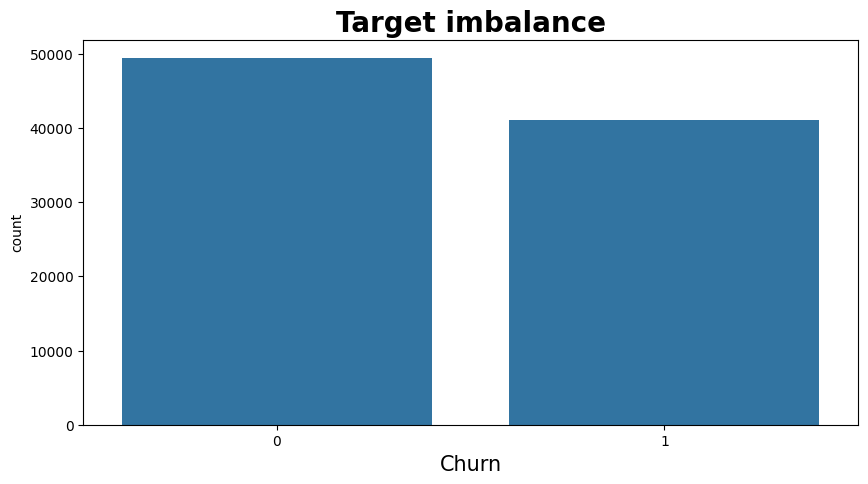

In [42]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Churn', data=final_outlierTreated)
plt.xlabel('Churn',color='black',fontsize=15)
plt.title('Target imbalance',color='black',fontsize=20,fontweight='bold')
plt.show()


**Observation:**
1. **Target variable is balanced**. So we **do not require upsampling** of the data using SMOTE. 

<a id="multivariate"></a>
## 13.2. Multivariate Analysis

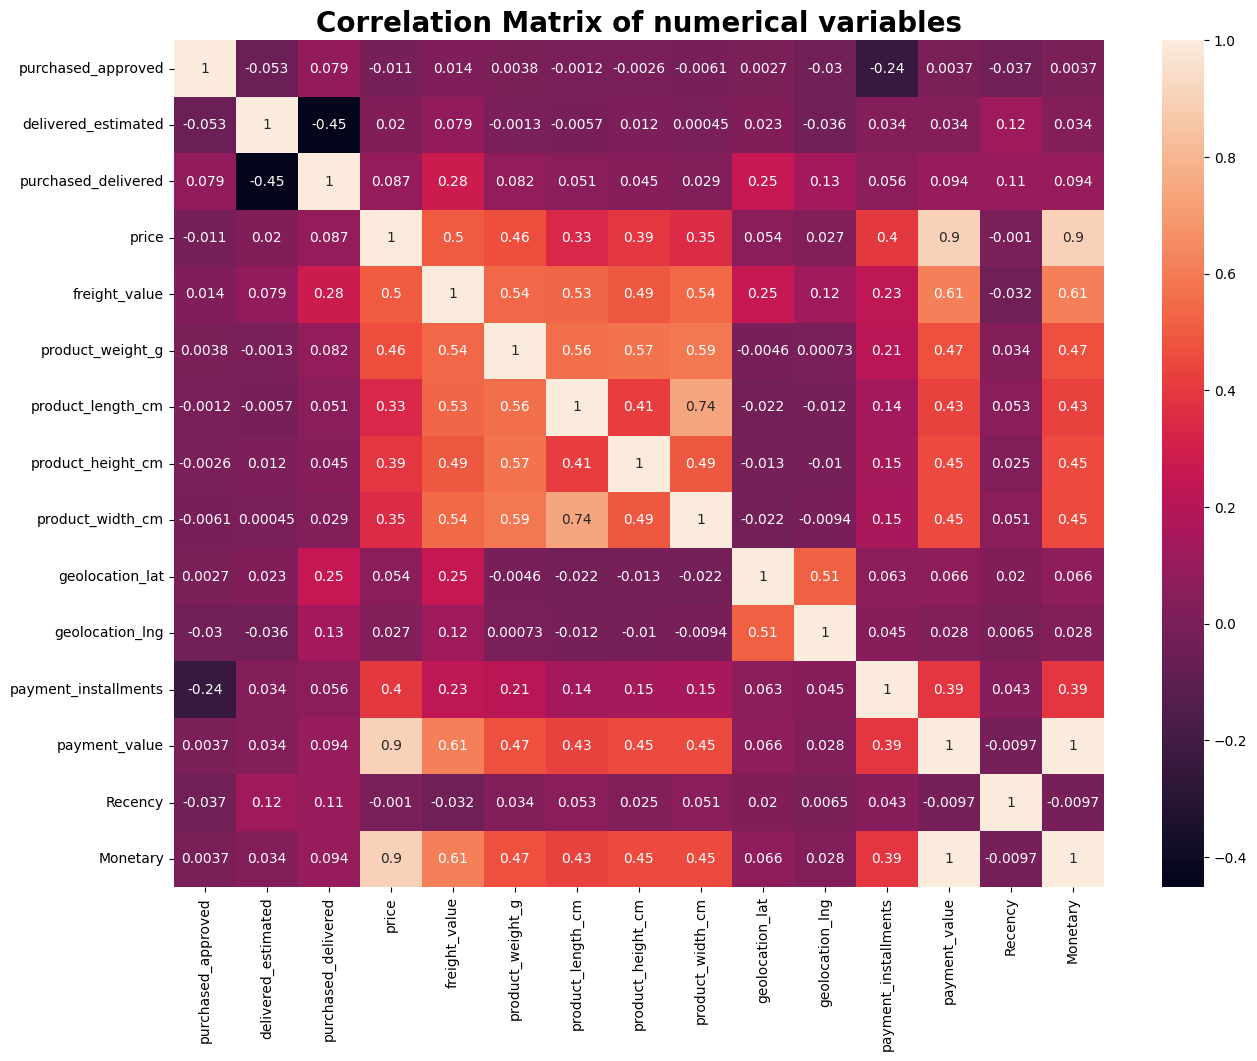

In [43]:
plt.figure(figsize=(15,11))
_corr28 = final_outlierTreated.select_dtypes(include=np.number).corr()
sns.heatmap(_corr28, annot = True)
plt.title('Correlation Matrix of numerical variables',fontsize=20,fontweight='bold')
plt.show()


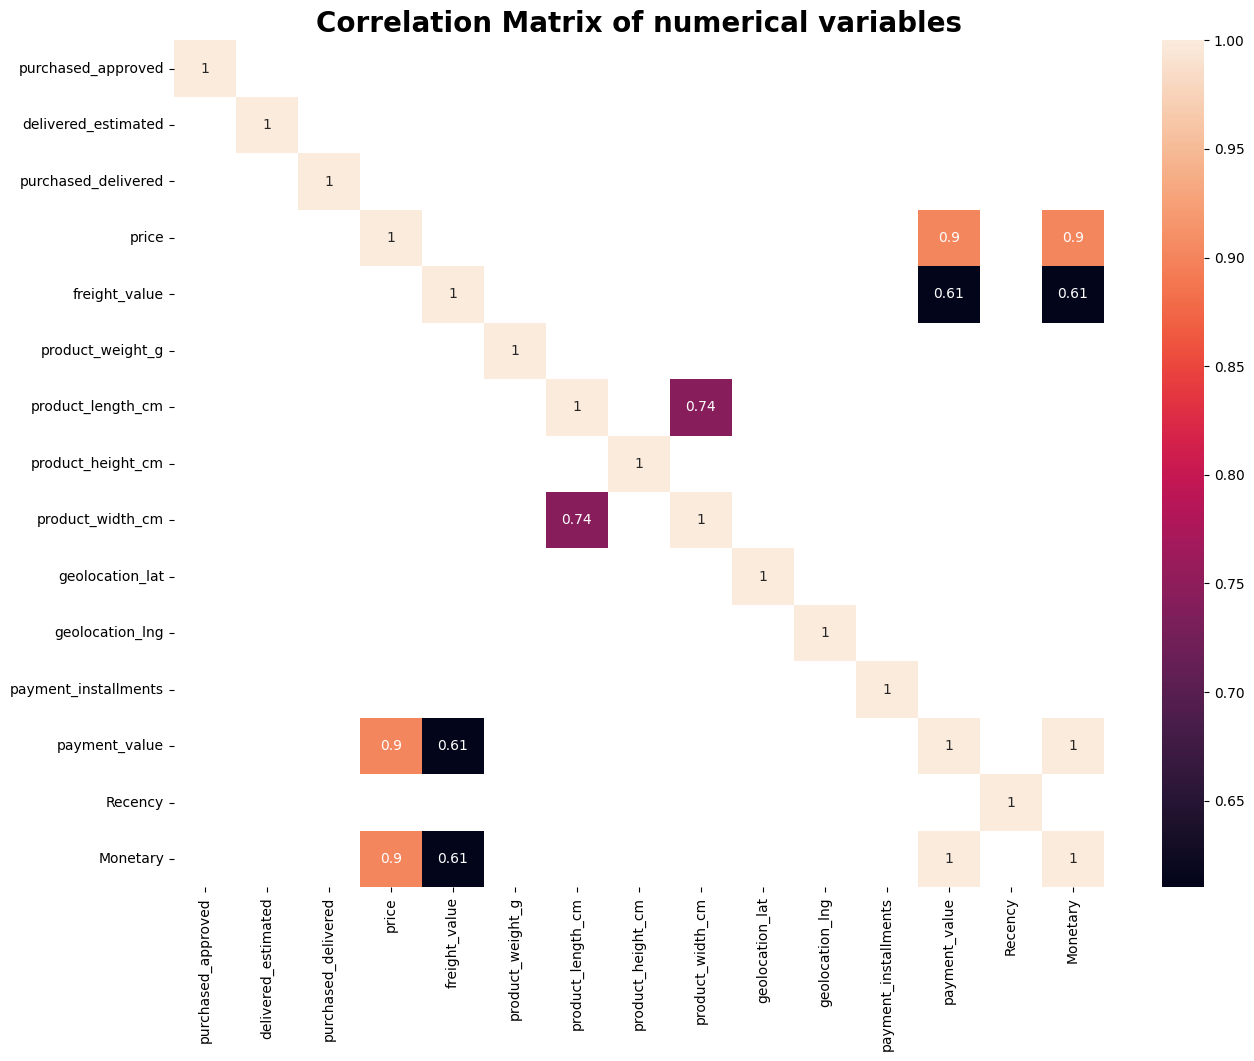

In [44]:
plt.figure(figsize=(15,11))
_corr29 = final_outlierTreated.select_dtypes(include=np.number).corr()
sns.heatmap(_corr29[_corr29 > 0.6], annot = True)
plt.title('Correlation Matrix of numerical variables',fontsize=20,fontweight='bold')
plt.show()


**Observations:**
1. The above heatmap of the correlation coefficients between numerical variables shows which variables are moderately to highly correlated between themselves. 
2. `product_width_cm` is **fairly correlated** with `product_length_cm`.
3. `freight_value` is **fairly correlated** with `Monetary` and `payment_value`, which both are the same. This variable would cause multi-collinearity, so it must be removed. 
4. Similarly, `price` is **highly correlated** with `Monetary` and `payment_value`. 

<a id="stats"></a>
# 14. Statistical Tests

### Statistical test for categorical and categorical variables 
**Chi-Squared test for Independence** <br><br>
**Hypothesis**<br>
**Null Hypothesis, H0**: Variables are independent.<br>
**Alternate Hypothesis, Ha**: Variables are dependent.

In [45]:
def cat_cat(variable):
    dependent_variables = []
    independent_variables = []
    for var in variable:
        print(f'{var} and Churn')
        observed = pd.crosstab(final_outlierTreated[var], final_outlierTreated.Churn)
        chi_stats, pval, dof, expected = stats.chi2_contingency(observed)
        print('test statistics: ', chi_stats)
        print('p - value: ', pval)
        print('degrees of freedom: ', dof)
        if pval < 0.05:
            print(f'Reject Null Hypothesis. \nThe variables {var} and target variable, Churn are dependent.\n')
            dependent_variables.append(var)
        else:
            print(f'Failed to reject Null Hypothesis. \nThe variables {var} and target variable, Churn are independent.\n')
            independent_variables.append(var)
    print('Dependent variables: ', dependent_variables)
    print('Independent variables: ', independent_variables)
        
variable = ['customer_state', 'payment_type', 'payment_installments', 'customer_city']
cat_cat(variable)

customer_state and Churn
test statistics:  353.9562373606318
p - value:  2.9132771252108942e-59
degrees of freedom:  26
Reject Null Hypothesis. 
The variables customer_state and target variable, Churn are dependent.

payment_type and Churn
test statistics:  266.16944819672017
p - value:  2.0805608001059732e-57
degrees of freedom:  3
Reject Null Hypothesis. 
The variables payment_type and target variable, Churn are dependent.

payment_installments and Churn
test statistics:  489.01783336833216
p - value:  1.2904748666154383e-99
degrees of freedom:  9
Reject Null Hypothesis. 
The variables payment_installments and target variable, Churn are dependent.

customer_city and Churn
test statistics:  4523.939055252141
p - value:  1.825636599597893e-08
degrees of freedom:  4011
Reject Null Hypothesis. 
The variables customer_city and target variable, Churn are dependent.

Dependent variables:  ['customer_state', 'payment_type', 'payment_installments', 'customer_city']
Independent variables:  []


### Statistical test for categorical and numerical variables 
**ANOVA test for Independence**<br><br>
**Hypothesis**<br>
**Null Hypothesis, H0**: Variables are not correlated with each other.<br>
**Alternate Hypothesis, Ha**: Variables are correlated with each other.

In [46]:
def num_cat(variable):
    correlated_variables = []
    noncorrelated_variables = []
    for var in variable:
        print(f'{var} Vs. target variable, Churn')
        churn = final[final.Churn == 1][var]
        not_churn = final[final.Churn == 0][var]
        test_stats, churn_pval = stats.shapiro(churn)
        test_stats, notchurn_pval = stats.shapiro(not_churn)
        if churn_pval < 0.05:
            print(f'churn of {var} is not normal')
        else: 
            print(f'churn of {var} is normal')
        if notchurn_pval < 0.05:
            print(f'not churn of {var} is not normal')
        else: 
            print(f'not churn of {var} is normal')
        levene_teststats, pval_levene = stats.levene(churn, not_churn)
        if pval_levene < 0.05:
            print(f'atleast one variance is not equal')
        else: 
            print(f'all variances are equal')
        anova_teststats, pval_anova = stats.f_oneway(churn, not_churn)
        if pval_anova < 0.05:
            print(f'Reject Null Hypothesis. \nThe variables {var} and target variable, Churn are correlated with each other.\n')
            correlated_variables.append(var)
        else:
            print(f'Failed to reject Null Hypothesis. \nThe variables {var} and target variable, Churn are not correlated with each other.\n')
            noncorrelated_variables.append(var)
            
    print('Correlated variables: ', correlated_variables)
    print('Non-correlated variables: ', noncorrelated_variables)

            
variable = ['purchased_approved', 'delivered_estimated', 'purchased_delivered', 'price', 'freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'geolocation_lat', 'geolocation_lng', 'Recency', 'Monetary']
num_cat(variable)

purchased_approved Vs. target variable, Churn
churn of purchased_approved is not normal
not churn of purchased_approved is not normal
atleast one variance is not equal
Reject Null Hypothesis. 
The variables purchased_approved and target variable, Churn are correlated with each other.

delivered_estimated Vs. target variable, Churn
churn of delivered_estimated is not normal
not churn of delivered_estimated is not normal
atleast one variance is not equal
Reject Null Hypothesis. 
The variables delivered_estimated and target variable, Churn are correlated with each other.

purchased_delivered Vs. target variable, Churn
churn of purchased_delivered is not normal
not churn of purchased_delivered is not normal
atleast one variance is not equal
Reject Null Hypothesis. 
The variables purchased_delivered and target variable, Churn are correlated with each other.

price Vs. target variable, Churn
churn of price is not normal
not churn of price is not normal
all variances are equal
Failed to rejec

In [47]:
def non_parametric_tests(variable):
    correlated_variables = []
    noncorrelated_variables = []
    for var in variable:
        test_stats, pval = stats.mannwhitneyu(final_outlierTreated[final_outlierTreated.Churn == 1][var], final_outlierTreated[final_outlierTreated.Churn == 0][var])
        if pval < 0.05:
            print(f'Reject Null Hypothesis. \nThe variables {var} and target variable, Churn are correlated with each other.\n')
            correlated_variables.append(var)
        else:
            print(f'Failed to reject Null Hypothesis. \nThe variables {var} and target variable, Churn are not correlated with each other.\n')
            noncorrelated_variables.append(var)
    print(f'Correlated variables: ', correlated_variables)
    print(f'Non correlated variables: ', noncorrelated_variables)
        
variable = ['purchased_approved', 'delivered_estimated', 'purchased_delivered', 'price', 'freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'geolocation_lat', 'geolocation_lng', 'Recency', 'Monetary']
non_parametric_tests(variable)

Reject Null Hypothesis. 
The variables purchased_approved and target variable, Churn are correlated with each other.

Reject Null Hypothesis. 
The variables delivered_estimated and target variable, Churn are correlated with each other.

Reject Null Hypothesis. 
The variables purchased_delivered and target variable, Churn are correlated with each other.

Failed to reject Null Hypothesis. 
The variables price and target variable, Churn are not correlated with each other.

Reject Null Hypothesis. 
The variables freight_value and target variable, Churn are correlated with each other.

Reject Null Hypothesis. 
The variables product_weight_g and target variable, Churn are correlated with each other.

Reject Null Hypothesis. 
The variables product_length_cm and target variable, Churn are correlated with each other.

Reject Null Hypothesis. 
The variables product_height_cm and target variable, Churn are correlated with each other.

Reject Null Hypothesis. 
The variables product_width_cm and ta

**Observations:**
1. **All the categorical variables** are **dependant** on the **target variable**. 
2. **The numerical variables**, which fail the normality test, when done non-parametric tests, are **all correlated** with the **target variable**, except for `price`. 

<a id="trans"></a>
# 15. Transformation of Data

In [48]:
transformed_data = final_outlierTreated.copy()
transformed_data['Churn'] = transformed_data['Churn'].astype('object')

In [49]:
transformed_data.select_dtypes(include=np.number).skew()


purchased_approved      1.216428
delivered_estimated    -0.098746
purchased_delivered     0.875670
price                   1.062169
freight_value           0.984423
product_weight_g        1.184709
product_length_cm       1.091731
product_height_cm       0.982845
product_width_cm        1.125375
geolocation_lat         0.530418
geolocation_lng         0.279777
payment_installments    1.211869
payment_value           1.092586
Recency                 0.435859
Monetary                1.092586
dtype: float64

In [50]:
transformed_data.describe()

,purchased_approved,delivered_estimated,purchased_delivered,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat,geolocation_lng,payment_installments,payment_value,Recency,Monetary
count,90528.000000,90528.000000,90528.00000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000,90528.000000
mean,10218.436257,10.918180,11.54482,118.080877,21.391276,1627.081113,34.209084,18.046422,26.419865,-21.859878,-46.111407,2.837614,152.703864,238.733773,152.703864
std,15172.739926,8.274096,7.11531,92.200444,11.097660,1768.577396,18.785326,12.625084,14.460755,3.670463,3.801225,2.439671,117.114715,152.386694,117.114715
min,0.000000,-9.000000,0.00000,0.850000,0.000000,0.000000,7.000000,2.000000,6.000000,-28.882827,-54.921403,0.000000,9.590000,1.000000,9.590000
25%,756.000000,6.000000,6.00000,48.900000,14.100000,304.000000,19.000000,9.000000,15.000000,-23.578469,-48.060327,1.000000,63.790000,115.000000,63.790000
50%,1164.000000,11.000000,10.00000,89.900000,17.670000,800.000000,29.000000,15.000000,21.000000,-22.898404,-46.614879,2.000000,112.830000,220.000000,112.830000
75%,16142.250000,16.000000,15.00000,159.900000,26.550000,2283.000000,43.000000,24.000000,34.000000,-20.042230,-43.486277,4.000000,202.122500,347.000000,202.122500
max,39221.625000,31.000000,28.50000,326.400000,45.225000,5251.500000,79.000000,46.500000,62.500000,-14.737871,-36.625202,8.500000,409.621250,695.000000,409.621250


In [51]:
pt = PowerTransformer(method = 'yeo-johnson')
for var in transformed_data:
    if var in ['delivered_estimated','geolocation_lat','geolocation_lng']:
        transformed_data[var] = pt.fit_transform(transformed_data[[var]])

In [52]:
pt = PowerTransformer(method='box-cox')
for var in transformed_data.select_dtypes(include=np.number):
    if var not in ['delivered_estimated','geolocation_lat','geolocation_lng']:
        transformed_data[var] = pt.fit_transform(0.001 + transformed_data[[var]])

In [53]:
transformed_data.select_dtypes(include=np.number).skew()


purchased_approved      0.136317
delivered_estimated     0.102573
purchased_delivered    -0.025024
price                  -0.029814
freight_value           0.177740
product_weight_g       -0.004216
product_length_cm       0.101678
product_height_cm      -0.033945
product_width_cm        0.070255
geolocation_lat         0.032696
geolocation_lng        -0.013325
payment_installments   -0.367193
payment_value          -0.000312
Recency                -0.161802
Monetary               -0.000312
dtype: float64

**Observations:**
1. The variables which have **negative values** are transformed using **yeo-johnson** method, as log of 0 or negative values would return infinite value. 
2. The variables which has **only positive values** in it are transformed using **box-cox** method. 

In [54]:
# Save preprocessed features and target for use in Notebook 4
X = transformed_data.drop(columns=['Churn'])
df_target = transformed_data[['Churn']].astype(int)
X.to_csv("X_features.csv", index=False)
df_target.to_csv("y_target.csv", index=False)
print("Saved X_features.csv and y_target.csv")


Saved X_features.csv and y_target.csv
